# Synthetic MV Ternary-Tree UQ Scaling

## tl;dr

This benchmark compares deterministic SE, analytical UQ, Monte Carlo UQ, and two conventional NRSE gain-matrix inversions on the original balanced ternary MV radial tree. The network sizes are 10, 20, 50, 100, 200, 500, 1,000, 2,000, and 5,000 buses. Monte Carlo is evaluated with `N = 30`, `100`, and `1,000` samples. The inverse baselines time `np.linalg.inv(G)` on dense $G$ and `scipy.sparse.linalg.inv(G)` on sparse $G$ after analytically building $H$, diagonal $W$, and $G=H^\mathsf{T}WH$ at the converged NRSE state.

With four BLAS threads, the recorded dense inversions range from 0.00007 s at 10 buses to 12.60 s at 5,000 buses. The recorded SciPy sparse inversions range from 0.0011 s at 10 buses to 6.72 s at 5,000 buses; every measured sparse inverse has density 1.0, so the explicit covariance loses the sparsity of $G$. The two 5,000-bus cases were run in isolated processes after checking 52 GiB of available host memory. Dense NumPy peaked at 2.59 GiB resident memory, while sparse SciPy peaked at 4.98 GiB and stored a 1.12 GiB CSC inverse. For context, the separately recorded 5,000-bus full-method calls took about 0.04/0.04 s for deterministic ILSE/NRSE, 1.07/1.47 s for analytical UQ ILSE/NRSE, and 0.67/0.93 s (N=30), 2.97/3.27 s (N=100), and 28.50/21.69 s (N=1,000) for Monte Carlo ILSE/NRSE. The versioned notebook embeds the SE/UQ timings recorded on 2026-08-18 and both inverse series recorded on 2026-08-21, so its default execution refreshes tables and figures without repeating the high-memory benchmark.


## Context & Methods

The real networks used by the other examples have different sizes, depths, measurement layouts, and electrical parameters. This notebook controls those factors by generating balanced ternary radial trees with the same MV electrical model and sensor layout for every size.

The benchmark reports:

1. deterministic ILSE and NRSE without uncertainty propagation;
2. analytical UQ ILSE and NRSE with uncertainty propagation;
3. Monte Carlo ILSE and NRSE with `N = 30`, `100`, and `1,000` perturbed measurement samples;
4. conventional dense NRSE state covariance from $G^{-1}$, timing only the NumPy inversion; and
5. the same conventional covariance using a sparse SciPy gain matrix and sparse inverse call.

### Solver and uncertainty distinction

| Method | State estimator / operating point | Uncertainty calculation | Timed result |
|---|---|---|---|
| Deterministic ILSE | Iterative linear | None | Model construction + deterministic SE |
| Deterministic NRSE | Newton–Raphson | None | Model construction + deterministic SE |
| Analytical UQ ILSE | Iterative linear | PGM analytical propagation | Model construction + SE and output UQ |
| Analytical UQ NRSE | Newton–Raphson | PGM analytical propagation | Model construction + SE and output UQ |
| Monte Carlo ILSE / NRSE | Iterative linear / Newton–Raphson | Repeated SE with `N = 30`, `100`, or `1,000` | Model construction + batched SE |
| Dense gain inverse (NumPy, NRSE) | Converged deterministic NRSE state | Conventional $G^{-1}$ state covariance | `np.linalg.inv(G)` only |
| Sparse gain inverse (SciPy, NRSE) | Converged deterministic NRSE state | Conventional $G^{-1}$ state covariance | `scipy.sparse.linalg.inv(G)` only |

Both inverse baselines follow the conventional real-polar WLS construction described by Abur and Gómez Expósito and illustrated by [pandapower's pinned WLS implementation](https://github.com/e2nIEE/pandapower/blob/be3f13b6db3632fe690f997654d15c9173a14839/pandapower/estimation/algorithm/base.py#L82-L164). The separate `gain_matrix.py` example helper analytically builds the branch-power and voltage rows of $H$ and diagonal $W$ from the sensor variances. The dense path forms dense $G=H^\mathsf{T}WH$ and calls [NumPy `inv`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.inv.html). The sparse path converts $H$ to SciPy CSR, forms sparse CSC $G$, and calls [SciPy sparse `inv`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.linalg.inv.html).

The two explicit inverses are frozen NRSE **state-covariance** baselines. Unlike PGM's analytical UQ calls, they exclude deterministic NRSE, $H/W/G$ construction, and propagation from state covariance to every node and branch output. Their timings are therefore informative about the inversion kernels, not end-to-end replacements. SciPy notes that when the inverse is expected to be non-sparse, converting to dense and using a dense inverse is likely faster. This network's measured sparse inverses are fully populated, although the recorded SciPy kernel becomes faster than NumPy at 5,000 buses on this environment.

### Key assumptions

- Every non-root bus has one fixed-PQ load; there are no PV generators or voltage regulators.
- The root is a 20 kV slack/source bus and each branch is active, producing a radial network.
- Each branching node has three children, so branching occurs at every depth level.
- Four voltage-magnitude measurements are spread across the tree, including the root; one P/Q power sensor is placed at the to-terminal of every branch.
- The root voltage sensor supplies a physical angle measurement. Every other bus has an active unmeasured load, so this case has no exact zero-injection constraints and the conventional gain inverse is applicable.
- Measurements are initialized at the deterministic power-flow solution; uncertainty enters through the configured sensor sigmas and Monte Carlo updates.
- Network construction, deterministic power flow, sensor creation, and Monte Carlo update generation are excluded from the recorded SE/UQ calls.
- The Monte Carlo sample count is varied explicitly because its computational cost is expected to scale with `N`.
- The recorded inversions used a four-thread environment cap. An opt-in notebook refresh forces that environment before NumPy/SciPy import in a fresh kernel and applies separate conservative 1 GiB working-set guards. The guard is a portable default, not a numerical limit. The 5,000-bus dense point was measured separately with a 6 GiB process limit. The 2,000- and 5,000-bus sparse points used isolated 4 GiB and 12 GiB process limits after confirming sufficient host memory. The default notebook path reads these embedded results without repeating their allocations.


In [1]:
import gc
import os
import sys
from pathlib import Path
from time import perf_counter

refresh_se_uq_timings = False
refresh_dense_gain_inverse_timings = False
refresh_sparse_gain_inverse_timings = False
gain_inverse_blas_threads = 4
if refresh_se_uq_timings or refresh_dense_gain_inverse_timings or refresh_sparse_gain_inverse_timings:
    if "numpy" in sys.modules:
        raise RuntimeError("Restart the kernel before enabling a timing refresh so the BLAS cap can be forced.")
    for thread_variable in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS"):
        os.environ[thread_variable] = str(gain_inverse_blas_threads)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy.sparse import csr_array, diags
from scipy.sparse.linalg import inv as sparse_inv

import power_grid_model
from power_grid_model import (
    AttributeType,
    CalculationMethod,
    CalculationType,
    ComponentType,
    DatasetType,
    LoadGenType,
    MeasuredTerminalType,
    PowerGridModel,
    initialize_array,
)
from power_grid_model._core.power_grid_model_c.get_pgm_dll_path import get_pgm_dll_path
from power_grid_model.utils import create_state_estimation_monte_carlo_updates
from power_grid_model.validation import assert_valid_input_data

example_directory = Path("docs/examples") if Path("docs/examples").is_dir() else Path()
example_directory_string = str(example_directory.resolve())
if example_directory_string not in sys.path:
    sys.path.insert(0, example_directory_string)
from gain_matrix import build_gain_matrix, build_measurement_model

output_directory = example_directory / "output/synthetic_mv_ternary_tree_uq_scaling"
output_directory.mkdir(parents=True, exist_ok=True)
figure_directory = output_directory / "figures"
figure_directory.mkdir(parents=True, exist_ok=True)

node_counts = [10, 20, 50, 100, 200, 500, 1_000, 2_000, 5_000]
se_uq_refresh_node_counts = node_counts[:-1]
monte_carlo_sample_counts = [30, 100, 1_000]
timing_repeats = 1
solver_error_tolerance = 1e-4
solver_max_iterations = 100
gain_inverse_working_set_limit_gib = 1.0
gain_inverse_working_set_factor = 4.0
sparse_inverse_working_set_limit_gib = 1.0
sparse_inverse_working_set_factor = 6.0


def estimated_gain_inverse_working_set_gib(node_count):
    state_dimension = 2 * node_count
    gain_size_gib = state_dimension**2 * np.dtype(np.float64).itemsize / 1024**3
    return gain_inverse_working_set_factor * gain_size_gib


def estimated_sparse_inverse_working_set_gib(node_count):
    state_dimension = 2 * node_count
    dense_sparse_output_bytes = (
        state_dimension**2 * (np.dtype(np.float64).itemsize + np.dtype(np.int64).itemsize)
        + (state_dimension + 1) * np.dtype(np.int64).itemsize
    )
    return sparse_inverse_working_set_factor * dense_sparse_output_bytes / 1024**3


blas_configuration = np.__config__.CONFIG.get("Build Dependencies", {}).get("blas", {})
print("Python:", sys.executable)
print("Power Grid Model package:", power_grid_model.__file__)
print("Native library:", get_pgm_dll_path())
print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("NumPy BLAS:", blas_configuration.get("name"), blas_configuration.get("version"))
timing_mode = "embedded recorded timings"
if refresh_se_uq_timings or refresh_dense_gain_inverse_timings or refresh_sparse_gain_inverse_timings:
    timing_mode = "opt-in timing refresh"
print("Timing mode:", timing_mode)
print("Dense inverse BLAS threads (recorded or forced before NumPy import):", gain_inverse_blas_threads)
print("Dense inverse working-set limit [GiB]:", gain_inverse_working_set_limit_gib)
print("Sparse inverse working-set limit [GiB]:", sparse_inverse_working_set_limit_gib)
print("Node counts:", node_counts)
print("Monte Carlo samples per size:", monte_carlo_sample_counts)

Python: /home/jhe/pgm_dev/power-grid-model/.venv/bin/python
Power Grid Model package: /home/jhe/pgm_dev/power-grid-model/src/power_grid_model/__init__.py
Native library: /home/jhe/pgm_dev/power-grid-model/build/bin/libpower_grid_model_c.so
NumPy: 2.5.1
SciPy: 1.18.0
NumPy BLAS: scipy-openblas 0.3.33.112.0
Timing mode: embedded recorded timings
Dense inverse BLAS threads (recorded or forced before NumPy import): 4
Dense inverse working-set limit [GiB]: 1.0
Sparse inverse working-set limit [GiB]: 1.0
Node counts: [10, 20, 50, 100, 200, 500, 1000, 2000, 5000]
Monte Carlo samples per size: [30, 100, 1000]


## Generate synthetic MV networks

A node with index `i > 0` has parent `(i - 1) // 3`. This creates the original balanced ternary tree: the root has three children, every next-level node has three children, and the final level is truncated to obtain the exact requested node count.

In [2]:
def build_ternary_mv_network(node_count):
    """Build an exact-size balanced ternary radial network at 20 kV."""
    if node_count < 2:  # noqa: PLR2004
        raise ValueError("The synthetic network needs at least two buses.")

    node = initialize_array(DatasetType.input, ComponentType.node, node_count)
    node[AttributeType.id] = np.arange(node_count)
    node[AttributeType.u_rated] = 20_000.0

    line_count = node_count - 1
    child_ids = np.arange(1, node_count)
    line = initialize_array(DatasetType.input, ComponentType.line, line_count)
    line[AttributeType.id] = np.arange(node_count, node_count + line_count)
    line[AttributeType.from_node] = (child_ids - 1) // 3
    line[AttributeType.to_node] = child_ids
    line[AttributeType.from_status] = 1
    line[AttributeType.to_status] = 1
    line[AttributeType.r1] = 0.04
    line[AttributeType.x1] = 0.08
    line[AttributeType.c1] = 0.0
    line[AttributeType.tan1] = 0.0
    line[AttributeType.i_n] = 1.0e9
    line[AttributeType.r0] = 0.04
    line[AttributeType.x0] = 0.08
    line[AttributeType.c0] = 0.0
    line[AttributeType.tan0] = 0.0

    load = initialize_array(DatasetType.input, ComponentType.sym_load, line_count)
    load[AttributeType.id] = np.arange(node_count + line_count, node_count + 2 * line_count)
    load[AttributeType.node] = child_ids
    load[AttributeType.status] = 1
    load[AttributeType.type] = LoadGenType.const_power
    load_scale = 1.0 + 0.15 * np.sin(0.37 * child_ids)
    load[AttributeType.p_specified] = 1_000.0 * load_scale
    load[AttributeType.q_specified] = 300.0 * load_scale

    source = initialize_array(DatasetType.input, ComponentType.source, 1)
    source[AttributeType.id] = [node_count + 2 * line_count]
    source[AttributeType.node] = [0]
    source[AttributeType.status] = [1]
    source[AttributeType.u_ref] = [1.0]
    if "u_ref_angle" in source.dtype.names:
        source[AttributeType.u_ref_angle] = [0.0]

    depth = np.zeros(node_count, dtype=int)
    for child_id in child_ids:
        depth[child_id] = depth[(child_id - 1) // 3] + 1

    return {
        ComponentType.node: node,
        ComponentType.line: line,
        ComponentType.sym_load: load,
        ComponentType.source: source,
    }, int(depth.max())


def make_state_estimation_input(base_input_data):
    """Create an IEEE33-style sensor layout from one deterministic power flow."""
    power_flow = PowerGridModel(base_input_data, system_frequency=50.0).calculate_power_flow(
        symmetric=True,
        calculation_method=CalculationMethod.newton_raphson,
        error_tolerance=1e-8,
        max_iterations=100,
    )
    input_data = {component: values.copy() for component, values in base_input_data.items()}
    node_ids = input_data[ComponentType.node][AttributeType.id].astype(int)
    line = input_data[ComponentType.line]
    line_ids = line[AttributeType.id].astype(int)
    voltage_sensor_ids = np.unique(np.linspace(0, len(node_ids) - 1, min(4, len(node_ids)), dtype=int))
    voltage_index = voltage_sensor_ids.astype(int)

    voltage_sensor = initialize_array(DatasetType.input, ComponentType.sym_voltage_sensor, len(voltage_sensor_ids))
    voltage_sensor[AttributeType.id] = np.arange(100_000, 100_000 + len(voltage_sensor_ids))
    voltage_sensor[AttributeType.measured_object] = voltage_sensor_ids
    voltage_sensor[AttributeType.u_sigma] = 30.0
    voltage_sensor[AttributeType.u_measured] = power_flow[ComponentType.node][AttributeType.u][voltage_index]
    voltage_sensor[AttributeType.u_angle_measured] = np.nan
    voltage_sensor[AttributeType.u_angle_measured][0] = power_flow[ComponentType.node][AttributeType.u_angle][0]

    power_sensor = initialize_array(DatasetType.input, ComponentType.sym_power_sensor, len(line_ids))
    power_sensor[AttributeType.id] = np.arange(
        100_000 + len(voltage_sensor_ids),
        100_000 + len(voltage_sensor_ids) + len(line_ids),
    )
    power_sensor[AttributeType.measured_object] = line_ids
    power_sensor[AttributeType.measured_terminal_type] = MeasuredTerminalType.branch_to
    power_sensor[AttributeType.p_sigma] = 25_000.0
    power_sensor[AttributeType.q_sigma] = 10_000.0
    power_sensor[AttributeType.p_measured] = power_flow[ComponentType.line][AttributeType.p_to]
    power_sensor[AttributeType.q_measured] = power_flow[ComponentType.line][AttributeType.q_to]

    input_data[ComponentType.sym_voltage_sensor] = voltage_sensor
    input_data[ComponentType.sym_power_sensor] = power_sensor
    return input_data


benchmark_inputs = {}
benchmark_input_node_counts = set()
if refresh_se_uq_timings:
    benchmark_input_node_counts.update(se_uq_refresh_node_counts)
if refresh_dense_gain_inverse_timings:
    benchmark_input_node_counts.update(
        node_count
        for node_count in node_counts
        if estimated_gain_inverse_working_set_gib(node_count) <= gain_inverse_working_set_limit_gib
    )
if refresh_sparse_gain_inverse_timings:
    benchmark_input_node_counts.update(
        node_count
        for node_count in node_counts
        if estimated_sparse_inverse_working_set_gib(node_count) <= sparse_inverse_working_set_limit_gib
    )
network_rows = []
for node_count in node_counts:
    base_input_data, depth = build_ternary_mv_network(node_count)
    if node_count in benchmark_input_node_counts:
        state_estimation_input = make_state_estimation_input(base_input_data)
        assert_valid_input_data(
            state_estimation_input,
            calculation_type=CalculationType.state_estimation,
            symmetric=True,
        )
        benchmark_inputs[node_count] = state_estimation_input
    network_rows.append(
        {
            "buses": node_count,
            "lines": len(base_input_data[ComponentType.line]),
            "maximum depth": depth,
            "voltage sensors": min(4, node_count),
            "power sensors": node_count - 1,
        }
    )
    del base_input_data

network_summary = pd.DataFrame(network_rows)
network_summary

,buses,lines,maximum depth,voltage sensors,power sensors
0,10,9,2,4,9
1,20,19,3,4,19
2,50,49,4,4,49
3,100,99,4,4,99
4,200,199,5,4,199
5,500,499,6,4,499
6,1000,999,6,4,999
7,2000,1999,7,4,1999
8,5000,4999,8,4,4999


## Network family summary

The benchmark generates one radial ternary-tree network for each configured bus count. Every non-root bus has one connected load and the root has one source, so the generated networks have no exact zero-injection buses. The table below verifies those properties from each generated PGM input.

In [3]:
from pathlib import Path

network_summary_directory = Path("docs/examples") if Path("docs/examples").is_dir() else Path()
network_summary_directory_string = str(network_summary_directory.resolve())
if network_summary_directory_string not in sys.path:
    sys.path.insert(0, network_summary_directory_string)
from network_summary import network_statistics

network_family_rows = []
for node_count in node_counts:
    network_input, max_depth = build_ternary_mv_network(node_count)
    statistics = network_statistics(network_input)
    network_family_rows.append(
        {
            "Buses": statistics["buses"],
            "Lines": statistics["lines"],
            "Transformers": statistics["transformers"],
            "Sources": statistics["sources_in_service"],
            "Loads": statistics["loads_in_service"],
            "Generators": statistics["generators_in_service"],
            "Open branch elements": statistics["open_branch_elements"],
            "Zero-injection buses": statistics["zero_injection_buses"],
            "Maximum depth": max_depth,
            "Nominal voltage [kV]": ", ".join(f"{level:g}" for level in statistics["nominal_voltage_levels_kv"]),
        }
    )
network_family_summary = pd.DataFrame(network_family_rows)
network_family_summary

,Buses,Lines,Transformers,Sources,Loads,Generators,Open branch elements,Zero-injection buses,Maximum depth,Nominal voltage [kV]
0,10,9,0,1,9,0,0,0,2,20
1,20,19,0,1,19,0,0,0,3,20
2,50,49,0,1,49,0,0,0,4,20
3,100,99,0,1,99,0,0,0,4,20
4,200,199,0,1,199,0,0,0,5,20
5,500,499,0,1,499,0,0,0,6,20
6,1000,999,0,1,999,0,0,0,6,20
7,2000,1999,0,1,1999,0,0,0,7,20
8,5000,4999,0,1,4999,0,0,0,8,20


## Time the SE and UQ methods

The versioned cell below reconstructs the recorded table by default: SE/UQ rows are from 2026-08-18 and both inversion series are from 2026-08-21. This presentation-only path allocates neither Monte Carlo batches nor gain matrices. Set `refresh_se_uq_timings`, `refresh_dense_gain_inverse_timings`, or `refresh_sparse_gain_inverse_timings` before starting a fresh kernel to opt into new measurements. The default SE/UQ refresh list stops at 2,000 buses; the recorded 5,000-bus Monte Carlo rows are retained to avoid a roughly gigabyte-scale output batch.

When enabled, each deterministic, analytical, or Monte Carlo case receives one unmeasured warm-up and then one measured call. Its measured interval wraps `calculate_once()`, so it includes `PowerGridModel(...)` construction as well as `calculate_state_estimation()`. Network construction, sensor creation, and Monte Carlo update generation remain outside that interval.

Each inverse baseline first runs deterministic NRSE and analytically constructs $H$, diagonal $W$, and $G=H^\mathsf{T}WH$ outside the timer. The dense path materializes $G$ as a NumPy array; the sparse path keeps $H$, $W$, and $G$ in SciPy sparse formats. Each then makes one unmeasured warm-up call and one measured call to its inversion function, releasing the returned covariance after every call. Separate conservative working-set guards are checked before $G$ is built. The dense estimate allows four dense matrices; the sparse estimate assumes a fully populated sparse output plus solver storage. The default notebook refresh skips estimates above 1 GiB. The recorded large inverse points are explicit exceptions measured in fresh subprocesses after a host-capacity check: dense 5,000 used a 6 GiB limit and peaked at 2.59 GiB; sparse 2,000 used a 4 GiB limit and peaked at 0.90 GiB; sparse 5,000 used a 12 GiB limit and peaked at 4.98 GiB. These timing scopes are intentionally different and should not be read as an end-to-end speedup comparison.


In [4]:
gain_inverse_method_name = "Dense gain inverse (NumPy, NRSE)"
sparse_gain_inverse_method_name = "Sparse gain inverse (SciPy, NRSE)"
recorded_timing_seconds = {
    "Deterministic ILSE": [
        0.0002880060055758,
        0.0002623750006023329,
        0.0003153120051138,
        0.0003808279871009,
        0.0004902719992969651,
        0.0008737189928069,
        0.0027079120045527,
        0.0078908219875302,
        0.0409396420000121,
    ],
    "Deterministic NRSE": [
        0.0002444300043862,
        0.0002506359996914398,
        0.0003001280128955,
        0.0003511839895509,
        0.0004682180006057024,
        0.0010026489908341,
        0.0029042910027783,
        0.0053731679799966,
        0.040545474999817,
    ],
    "Analytical UQ ILSE": [
        0.0002424709964543,
        0.0002940240001407801,
        0.0004207599849905,
        0.0007630409963894,
        0.002049957000053837,
        0.0109121200221125,
        0.0430216940003447,
        0.1656960230029653,
        1.0680363939900417,
    ],
    "Analytical UQ NRSE": [
        0.000252989004366,
        0.00027206999948248267,
        0.000486106990138,
        0.0009909969812724,
        0.002837651999470836,
        0.0154442760103847,
        0.0594191009877249,
        0.2342166710004676,
        1.4676173540065065,
    ],
    gain_inverse_method_name: [
        6.982499999708125e-05,
        2.9502999495889526e-05,
        0.000234966999983,
        0.0005296820000069,
        0.002311227000063809,
        0.0227988329999959,
        0.1468999550000091,
        0.9335374379999736,
        12.598549587999969,
    ],
    sparse_gain_inverse_method_name: [
        0.0011208930000066175,
        0.0019897120000678115,
        0.00513892000026317,
        0.017004271000132576,
        0.02821663500071736,
        0.10665183399987654,
        0.33485111700019843,
        1.1806150180000259,
        6.717102595999677,
    ],
    "Monte Carlo ILSE (N=30)": [
        0.0005804260144941,
        0.0007759079999232199,
        0.0013283699809107,
        0.0021974139963276,
        0.004025263000585255,
        0.0123147199919912,
        0.0586217430245596,
        0.1586364099930506,
        0.6727835070050787,
    ],
    "Monte Carlo NRSE (N=30)": [
        0.0006756900111213,
        0.000925563999771839,
        0.0018457830010447,
        0.0030470000056084,
        0.005776037999567052,
        0.0169049680116586,
        0.0433690569770988,
        0.1556841059937141,
        0.932435719005298,
    ],
    "Monte Carlo ILSE (N=100)": [
        0.0011459160014055,
        0.0016024500000639819,
        0.0035778859746642,
        0.0063288069795817,
        0.01332599399938772,
        0.0350662569981068,
        0.108194093016209,
        0.4577030589862261,
        2.970516439003404,
    ],
    "Monte Carlo NRSE (N=100)": [
        0.0014587649784516,
        0.0021523639998122235,
        0.0052137989841867,
        0.0088930210040416,
        0.01894975999948656,
        0.0499718710198067,
        0.222253155981889,
        0.5283164420106914,
        3.272792090981966,
    ],
    "Monte Carlo ILSE (N=1,000)": [
        0.0087197410175576,
        0.01367995999953564,
        0.0302357019972987,
        0.0558168260031379,
        0.13060054299967305,
        0.3644834219885524,
        1.0909241629997268,
        5.9213571889849845,
        28.495918820000952,
    ],
    "Monte Carlo NRSE (N=1,000)": [
        0.0120164499967359,
        0.019792545000200334,
        0.0477343999955337,
        0.0846039909811224,
        0.1774375239992878,
        0.4973670750041492,
        2.166075163986534,
        4.5268472300085705,
        21.687024815008044,
    ],
}
recorded_monte_carlo_samples = {
    "Monte Carlo ILSE (N=30)": 30,
    "Monte Carlo NRSE (N=30)": 30,
    "Monte Carlo ILSE (N=100)": 100,
    "Monte Carlo NRSE (N=100)": 100,
    "Monte Carlo ILSE (N=1,000)": 1_000,
    "Monte Carlo NRSE (N=1,000)": 1_000,
}
recorded_dense_working_sets_gib = [estimated_gain_inverse_working_set_gib(node_count) for node_count in node_counts]
recorded_sparse_working_sets_gib = [estimated_sparse_inverse_working_set_gib(node_count) for node_count in node_counts]
recorded_sparse_inverse_densities = [1.0] * len(node_counts)
recorded_sparse_process_limits_gib = {2_000: 4, 5_000: 12}


def load_embedded_recorded_timings():
    rows = []
    for method_name, method_timings in recorded_timing_seconds.items():
        for index, (node_count, seconds) in enumerate(zip(node_counts, method_timings, strict=True)):
            is_dense = method_name == gain_inverse_method_name
            is_sparse = method_name == sparse_gain_inverse_method_name
            if is_dense and seconds is None:
                status = "skipped: estimated 2.98 GiB working set > 1.00 GiB limit"
            elif is_dense and node_count == max(node_counts):
                status = "recorded 2026-08-21: NumPy inversion only; isolated 6 GiB process limit"
            elif is_dense:
                status = "recorded 2026-08-21: NumPy inversion only"
            elif is_sparse and seconds is None:
                estimated_gib = recorded_sparse_working_sets_gib[index]
                if estimated_gib > sparse_inverse_working_set_limit_gib:
                    status = f"skipped: estimated {estimated_gib:.2f} GiB working set > 1.00 GiB limit"
                else:
                    status = "not recorded"
            elif is_sparse and node_count in recorded_sparse_process_limits_gib:
                process_limit_gib = recorded_sparse_process_limits_gib[node_count]
                status = (
                    f"recorded 2026-08-21: SciPy sparse inversion only; isolated {process_limit_gib} GiB process limit"
                )
            elif is_sparse:
                status = "recorded 2026-08-21: SciPy sparse inversion only"
            else:
                recording_date = "2026-08-21" if node_count in {20, 200} else "2026-08-18"
                status = f"recorded {recording_date}: model construction + SE/UQ call"
            rows.append(
                {
                    "buses": node_count,
                    "method": method_name,
                    "Monte Carlo samples": recorded_monte_carlo_samples.get(method_name, np.nan),
                    "median time [s]": seconds,
                    "minimum time [s]": seconds,
                    "maximum time [s]": seconds,
                    "estimated dense working set [GiB]": (
                        recorded_dense_working_sets_gib[index] if is_dense else np.nan
                    ),
                    "estimated sparse working set [GiB]": (
                        recorded_sparse_working_sets_gib[index] if is_sparse else np.nan
                    ),
                    "inverse density": (recorded_sparse_inverse_densities[index] if is_sparse else np.nan),
                    "benchmark status": status,
                }
            )
    return pd.DataFrame(rows)


recorded_timing_results = load_embedded_recorded_timings()

deterministic_methods = {
    "Deterministic ILSE": CalculationMethod.iterative_linear,
    "Deterministic NRSE": CalculationMethod.newton_raphson,
}
analytical_methods = {
    "Analytical UQ ILSE": CalculationMethod.iterative_linear,
    "Analytical UQ NRSE": CalculationMethod.newton_raphson,
}
monte_carlo_methods = {
    "Monte Carlo ILSE": CalculationMethod.iterative_linear,
    "Monte Carlo NRSE": CalculationMethod.newton_raphson,
}


def calculate_once(input_data, calculation_method, uq_kind, updates=None):
    model = PowerGridModel(input_data, system_frequency=50.0)
    if uq_kind == "deterministic":
        return model.calculate_state_estimation(
            calculation_method=calculation_method,
            error_tolerance=solver_error_tolerance,
            max_iterations=solver_max_iterations,
        )
    if uq_kind == "analytical":
        return model.calculate_state_estimation(
            calculation_method=calculation_method,
            calculate_uncertainty=True,
            error_tolerance=solver_error_tolerance,
            max_iterations=solver_max_iterations,
        )
    result = model.calculate_state_estimation(
        calculation_method=calculation_method,
        update_data=updates,
        error_tolerance=solver_error_tolerance,
        max_iterations=solver_max_iterations,
        continue_on_batch_error=True,
    )
    if model.batch_error is not None and model.batch_error.failed_scenarios:
        raise RuntimeError(f"Monte Carlo failed for scenarios {model.batch_error.failed_scenarios[:10]}")
    return result


def median_timing(input_data, calculation_method, uq_kind, updates=None):
    calculate_once(input_data, calculation_method, uq_kind, updates)
    elapsed = []
    for _ in range(timing_repeats):
        start = perf_counter()
        calculate_once(input_data, calculation_method, uq_kind, updates)
        elapsed.append(perf_counter() - start)
    return float(np.median(elapsed)), float(np.min(elapsed)), float(np.max(elapsed))


def median_gain_inverse_timing(input_data, node_count):
    if not refresh_dense_gain_inverse_timings:
        recorded_row = recorded_timing_results[
            (recorded_timing_results["buses"] == node_count)
            & (recorded_timing_results["method"] == gain_inverse_method_name)
        ].iloc[0]
        return (
            recorded_row["median time [s]"],
            recorded_row["minimum time [s]"],
            recorded_row["maximum time [s]"],
            recorded_row["estimated dense working set [GiB]"],
            recorded_row["benchmark status"],
        )

    estimated_working_set_gib = estimated_gain_inverse_working_set_gib(node_count)
    if estimated_working_set_gib > gain_inverse_working_set_limit_gib:
        status = (
            f"skipped: estimated {estimated_working_set_gib:.2f} GiB working set "
            f"> {gain_inverse_working_set_limit_gib:.2f} GiB limit"
        )
        return np.nan, np.nan, np.nan, estimated_working_set_gib, status

    gain_matrix = None
    covariance = None
    try:
        gain_matrix = build_gain_matrix(
            input_data,
            system_frequency=50.0,
            error_tolerance=solver_error_tolerance,
            max_iterations=solver_max_iterations,
        ).gain_matrix
        covariance = np.linalg.inv(gain_matrix)
        covariance = None

        elapsed = []
        for _ in range(timing_repeats):
            start = perf_counter()
            covariance = np.linalg.inv(gain_matrix)
            elapsed.append(perf_counter() - start)
            covariance = None
        return (
            float(np.median(elapsed)),
            float(np.min(elapsed)),
            float(np.max(elapsed)),
            estimated_working_set_gib,
            "measured this run: NumPy inversion only",
        )
    finally:
        del covariance
        del gain_matrix
        gc.collect()


def build_sparse_gain_matrix(input_data):
    measurement_model = build_measurement_model(
        input_data,
        system_frequency=50.0,
        error_tolerance=solver_error_tolerance,
        max_iterations=solver_max_iterations,
    )
    measurement_matrix = measurement_model.measurement_matrix
    sparse_measurement_matrix = csr_array(
        (
            measurement_matrix.data,
            measurement_matrix.column_indices,
            measurement_matrix.row_pointers,
        ),
        shape=measurement_matrix.shape,
    )
    sparse_weight_matrix = diags(measurement_model.weight_matrix.diagonal, format="csr")
    return (sparse_measurement_matrix.T @ sparse_weight_matrix @ sparse_measurement_matrix).tocsc()


def median_sparse_gain_inverse_timing(input_data, node_count):
    if not refresh_sparse_gain_inverse_timings:
        recorded_row = recorded_timing_results[
            (recorded_timing_results["buses"] == node_count)
            & (recorded_timing_results["method"] == sparse_gain_inverse_method_name)
        ].iloc[0]
        return (
            recorded_row["median time [s]"],
            recorded_row["minimum time [s]"],
            recorded_row["maximum time [s]"],
            recorded_row["estimated sparse working set [GiB]"],
            recorded_row["inverse density"],
            recorded_row["benchmark status"],
        )

    estimated_working_set_gib = estimated_sparse_inverse_working_set_gib(node_count)
    if estimated_working_set_gib > sparse_inverse_working_set_limit_gib:
        status = (
            f"skipped: estimated {estimated_working_set_gib:.2f} GiB working set "
            f"> {sparse_inverse_working_set_limit_gib:.2f} GiB limit"
        )
        return np.nan, np.nan, np.nan, estimated_working_set_gib, np.nan, status

    sparse_gain_matrix = None
    sparse_covariance = None
    inverse_density = np.nan
    try:
        sparse_gain_matrix = build_sparse_gain_matrix(input_data)
        sparse_covariance = sparse_inv(sparse_gain_matrix)
        inverse_density = sparse_covariance.nnz / np.prod(sparse_covariance.shape)
        sparse_covariance = None

        elapsed = []
        for _ in range(timing_repeats):
            start = perf_counter()
            sparse_covariance = sparse_inv(sparse_gain_matrix)
            elapsed.append(perf_counter() - start)
            sparse_covariance = None
        return (
            float(np.median(elapsed)),
            float(np.min(elapsed)),
            float(np.max(elapsed)),
            estimated_working_set_gib,
            float(inverse_density),
            "measured this run: SciPy sparse inversion only",
        )
    finally:
        del sparse_covariance
        del sparse_gain_matrix
        gc.collect()


timing_rows = []
for node_count, input_data in benchmark_inputs.items():
    for method_name, calculation_method in deterministic_methods.items() if refresh_se_uq_timings else ():
        median_seconds, minimum_seconds, maximum_seconds = median_timing(
            input_data, calculation_method, "deterministic"
        )
        timing_rows.append(
            {
                "buses": node_count,
                "method": method_name,
                "Monte Carlo samples": np.nan,
                "median time [s]": median_seconds,
                "minimum time [s]": minimum_seconds,
                "maximum time [s]": maximum_seconds,
            }
        )

    for method_name, calculation_method in analytical_methods.items() if refresh_se_uq_timings else ():
        median_seconds, minimum_seconds, maximum_seconds = median_timing(input_data, calculation_method, "analytical")
        timing_rows.append(
            {
                "buses": node_count,
                "method": method_name,
                "Monte Carlo samples": np.nan,
                "median time [s]": median_seconds,
                "minimum time [s]": minimum_seconds,
                "maximum time [s]": maximum_seconds,
            }
        )

    (
        median_seconds,
        minimum_seconds,
        maximum_seconds,
        estimated_working_set_gib,
        benchmark_status,
    ) = median_gain_inverse_timing(input_data, node_count)
    timing_rows.append(
        {
            "buses": node_count,
            "method": gain_inverse_method_name,
            "Monte Carlo samples": np.nan,
            "median time [s]": median_seconds,
            "minimum time [s]": minimum_seconds,
            "maximum time [s]": maximum_seconds,
            "estimated dense working set [GiB]": estimated_working_set_gib,
            "benchmark status": benchmark_status,
        }
    )

    (
        median_seconds,
        minimum_seconds,
        maximum_seconds,
        estimated_working_set_gib,
        inverse_density,
        benchmark_status,
    ) = median_sparse_gain_inverse_timing(input_data, node_count)
    timing_rows.append(
        {
            "buses": node_count,
            "method": sparse_gain_inverse_method_name,
            "Monte Carlo samples": np.nan,
            "median time [s]": median_seconds,
            "minimum time [s]": minimum_seconds,
            "maximum time [s]": maximum_seconds,
            "estimated sparse working set [GiB]": estimated_working_set_gib,
            "inverse density": inverse_density,
            "benchmark status": benchmark_status,
        }
    )

    for sample_count in monte_carlo_sample_counts if refresh_se_uq_timings else []:
        monte_carlo_update = create_state_estimation_monte_carlo_updates(input_data, sample_count, seed=2026)
        for method_name, calculation_method in monte_carlo_methods.items():
            median_seconds, minimum_seconds, maximum_seconds = median_timing(
                input_data,
                calculation_method,
                "monte_carlo",
                monte_carlo_update,
            )
            timing_rows.append(
                {
                    "buses": node_count,
                    "method": f"{method_name} (N={sample_count:,})",
                    "Monte Carlo samples": sample_count,
                    "median time [s]": median_seconds,
                    "minimum time [s]": minimum_seconds,
                    "maximum time [s]": maximum_seconds,
                }
            )
        del monte_carlo_update
        gc.collect()

refreshed_timing_results = pd.DataFrame(timing_rows)
if refreshed_timing_results.empty:
    timing_results = recorded_timing_results.copy()
else:
    refreshed_timing_results["benchmark status"] = refreshed_timing_results["benchmark status"].fillna(
        "measured this run: model construction + SE/UQ call"
    )
    refreshed_keys = pd.MultiIndex.from_frame(refreshed_timing_results[["buses", "method"]])
    recorded_keys = pd.MultiIndex.from_frame(recorded_timing_results[["buses", "method"]])
    timing_results = pd.concat(
        [recorded_timing_results[~recorded_keys.isin(refreshed_keys)], refreshed_timing_results],
        ignore_index=True,
    )
method_order = {method_name: index for index, method_name in enumerate(recorded_timing_seconds)}
timing_results["method order"] = timing_results["method"].map(method_order)
timing_results = (
    timing_results.sort_values(["buses", "method order"]).drop(columns="method order").reset_index(drop=True)
)
timing_file = output_directory / "synthetic_mv_ternary_tree_uq_timing.csv"
timing_results.to_csv(timing_file, index=False)
print(f"Timing results exported to {timing_file}")
display(
    timing_results[timing_results["buses"] == max(node_counts)][
        ["method", "Monte Carlo samples", "median time [s]", "benchmark status"]
    ].round(3)
)

deterministic_nrse_times = timing_results[timing_results["method"] == "Deterministic NRSE"].set_index("buses")[
    "median time [s]"
]
uq_timing_ratios = timing_results[
    timing_results["method"].str.startswith(("Analytical UQ", "Monte Carlo"))
    | timing_results["method"].isin([gain_inverse_method_name, sparse_gain_inverse_method_name])
].copy()
uq_timing_ratios["time / deterministic NRSE time"] = uq_timing_ratios["median time [s]"] / uq_timing_ratios[
    "buses"
].map(deterministic_nrse_times)
uq_timing_ratio_table = (
    uq_timing_ratios.pivot(
        index="buses",
        columns="method",
        values="time / deterministic NRSE time",
    )
    .sort_index()
    .round(2)
)
display(uq_timing_ratio_table)

Timing results exported to docs/examples/output/synthetic_mv_ternary_tree_uq_scaling/synthetic_mv_ternary_tree_uq_timing.csv


,method,Monte Carlo samples,median time [s],benchmark status
96,Deterministic ILSE,NaN,0.041,recorded 2026-08-18: model construction + SE/U...
97,Deterministic NRSE,NaN,0.041,recorded 2026-08-18: model construction + SE/U...
98,Analytical UQ ILSE,NaN,1.068,recorded 2026-08-18: model construction + SE/U...
99,Analytical UQ NRSE,NaN,1.468,recorded 2026-08-18: model construction + SE/U...
100,"Dense gain inverse (NumPy, NRSE)",NaN,12.599,recorded 2026-08-21: NumPy inversion only; iso...
101,"Sparse gain inverse (SciPy, NRSE)",NaN,6.717,recorded 2026-08-21: SciPy sparse inversion on...
102,Monte Carlo ILSE (N=30),30.0,0.673,recorded 2026-08-18: model construction + SE/U...
103,Monte Carlo NRSE (N=30),30.0,0.932,recorded 2026-08-18: model construction + SE/U...
104,Monte Carlo ILSE (N=100),100.0,2.971,recorded 2026-08-18: model construction + SE/U...
105,Monte Carlo NRSE (N=100),100.0,3.273,recorded 2026-08-18: model construction + SE/U...


method,Analytical UQ ILSE,Analytical UQ NRSE,"Dense gain inverse (NumPy, NRSE)","Monte Carlo ILSE (N=1,000)",Monte Carlo ILSE (N=100),Monte Carlo ILSE (N=30),"Monte Carlo NRSE (N=1,000)",Monte Carlo NRSE (N=100),Monte Carlo NRSE (N=30),"Sparse gain inverse (SciPy, NRSE)"
buses,,,,,,,,,,
10,0.99,1.04,0.29,35.67,4.69,2.37,49.16,5.97,2.76,4.59
20,1.17,1.09,0.12,54.58,6.39,3.10,78.97,8.59,3.69,7.94
50,1.40,1.62,0.78,100.74,11.92,4.43,159.05,17.37,6.15,17.12
100,2.17,2.82,1.51,158.94,18.02,6.26,240.91,25.32,8.68,48.42
200,4.38,6.06,4.94,278.93,28.46,8.60,378.96,40.47,12.34,60.26
500,10.88,15.40,22.74,363.52,34.97,12.28,496.05,49.84,16.86,106.37
1000,14.81,20.46,50.58,375.62,37.25,20.18,745.82,76.53,14.93,115.30
2000,30.84,43.59,173.74,1102.02,85.18,29.52,842.49,98.32,28.97,219.72
5000,26.34,36.20,310.73,702.81,73.26,16.59,534.88,80.72,23.00,165.67


## Results

The notebook exports two views of the same timing data: a log-log figure and a companion figure with a linear time axis. Both retain a logarithmic bus-count axis so that all requested network sizes remain readable. Deterministic and analytical SE are shown alongside Monte Carlo ILSE and NRSE for `N = 30`, `100`, and `1,000`, plus separate dense NumPy and sparse SciPy gain-inverse lines. Both inverse series now cover every requested size through 5,000 buses.

The timing table reports each UQ method's median time divided by deterministic NRSE time. This ratio is a visual normalization only: both inverse series cover inversion alone, whereas the other methods include model construction and their complete SE/UQ call. The CSV records timing scope, recording date, estimated working set, inverse density, and isolated-process limits explicitly.

The focused helper tests in `tests/unit/test_example_gain_matrix.py` independently compare analytical $H$ against central differences (including branch-from, branch-to, and shunt terms), verify $G=H^\mathsf{T}WH$, and compare the square root of the diagonal of $G^{-1}$ with PGM's node angle and voltage-magnitude sigmas on a small case. The isolated sparse benchmark also compares SciPy's sparse $G$ and inverse with the NumPy versions for 10, 50, and 100 buses before recording timings.


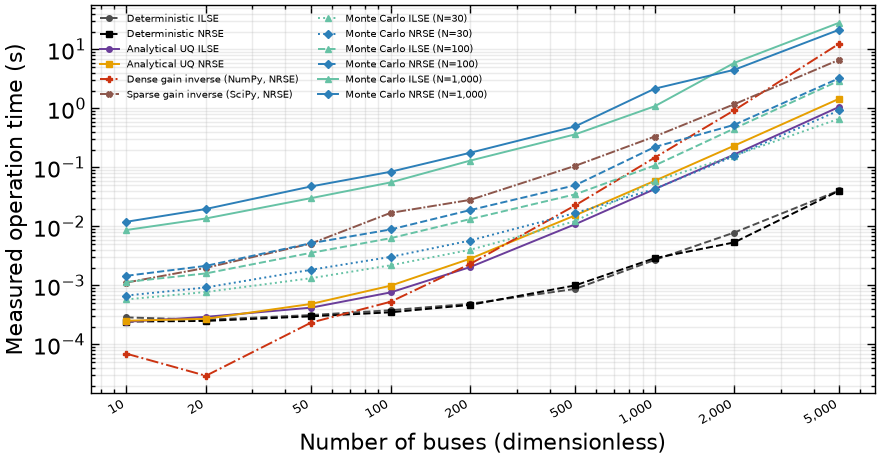

Log-log figure exported to docs/examples/output/synthetic_mv_ternary_tree_uq_scaling/figures


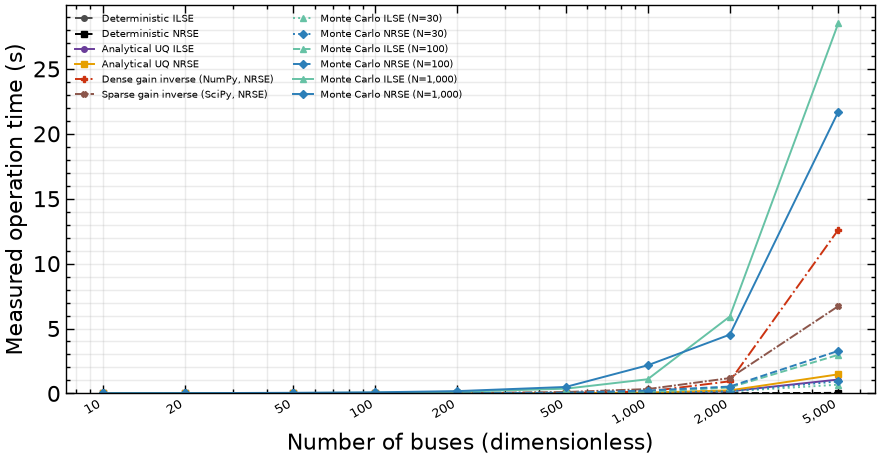

Linear-time figure exported to docs/examples/output/synthetic_mv_ternary_tree_uq_scaling/figures


In [5]:
try:
    import scienceplots  # noqa: F401
except ImportError:
    plot_style = ["default"]
else:
    plot_style = ["science", "notebook"]

plot_specs = [
    ("Deterministic ILSE", "#4D4D4D", "--", "o"),
    ("Deterministic NRSE", "#000000", "--", "s"),
    ("Analytical UQ ILSE", "#6A3D9A", "-", "o"),
    ("Analytical UQ NRSE", "#E69F00", "-", "s"),
    ("Dense gain inverse (NumPy, NRSE)", "#CC3311", "-.", "P"),
    ("Sparse gain inverse (SciPy, NRSE)", "#8C564B", (0, (5, 1, 1, 1)), "X"),
]
for sample_count, line_style in [(30, ":"), (100, "--"), (1_000, "-")]:
    plot_specs.extend(
        [
            (f"Monte Carlo ILSE (N={sample_count:,})", "#66C2A5", line_style, "^"),
            (f"Monte Carlo NRSE (N={sample_count:,})", "#2C7FB8", line_style, "D"),
        ]
    )


def plot_scaling_figure(scale_name, use_log_y, file_stem):
    with plt.style.context(plot_style), plt.rc_context({"text.usetex": False, "savefig.bbox": None}):
        figure, axis = plt.subplots(figsize=(9.0, 4.8))
        for method_name, color, line_style, marker in plot_specs:
            subset = (
                timing_results[timing_results["method"] == method_name]
                .dropna(subset=["median time [s]"])
                .sort_values("buses")
            )
            axis.plot(
                subset["buses"],
                subset["median time [s]"],
                label=method_name,
                color=color,
                linestyle=line_style,
                marker=marker,
                linewidth=1.4,
                markersize=4,
            )
        axis.set_xscale("log")
        if use_log_y:
            axis.set_yscale("log")
        else:
            axis.set_ylim(0, timing_results["median time [s]"].max() * 1.05)
        axis.set_xlabel("Number of buses (dimensionless)")
        axis.set_ylabel("Measured operation time (s)")
        axis.set_xticks(node_counts)
        axis.set_xticklabels([f"{count:,}" for count in node_counts])
        plt.setp(axis.get_xticklabels(), rotation=30, ha="right", fontsize=9)
        axis.grid(visible=True, which="both", alpha=0.25)
        axis.legend(fontsize=7, ncol=2)
        figure.tight_layout()
        figure.savefig(figure_directory / f"{file_stem}.pdf")
        figure.savefig(figure_directory / f"{file_stem}.svg")
        figure.savefig(figure_directory / f"{file_stem}.png", dpi=300)
        plt.show()
        plt.close(figure)
        print(f"{scale_name} figure exported to {figure_directory}")


plot_scaling_figure(
    "Log-log",
    use_log_y=True,
    file_stem="synthetic_mv_ternary_tree_uq_scaling",
)
plot_scaling_figure(
    "Linear-time",
    use_log_y=False,
    file_stem="synthetic_mv_ternary_tree_uq_scaling_linear_scale",
)

### Empirical computational scaling

For each method, fit the recorded high-end timings to

$$
\log t = \log C + p\log n,
$$

using 500, 1,000, 2,000, and 5,000 buses. The slope $p$ gives the empirical scaling law $t \propto n^p$. Because the state dimension grows linearly with the bus count in this balanced formulation, multiplying the bus count by a constant does not change $p$.

These fitted exponents are not formal asymptotic Big-O guarantees. They describe this synthetic radial topology, measurement layout, solver behavior, and machine. Each timing point uses one unmeasured warm-up followed by one measured call. The SE/UQ series include model construction and the SE/UQ call, whereas the two gain-inverse baselines time inversion only. The reported $R^2$ is a fit diagnostic, not a confidence interval.

In [6]:
scaling_fit_min_buses = 500
empirical_scaling_rows = []

for method_name, *_ in plot_specs:
    method_timings = (
        timing_results[(timing_results["method"] == method_name) & (timing_results["buses"] >= scaling_fit_min_buses)]
        .dropna(subset=["median time [s]"])
        .sort_values("buses")
    )
    minimum_fit_points = 3
    if len(method_timings) < minimum_fit_points:
        continue

    log_bus_count = np.log(method_timings["buses"].to_numpy(dtype=float))
    log_time = np.log(method_timings["median time [s]"].to_numpy(dtype=float))
    exponent, log_prefactor = np.polyfit(log_bus_count, log_time, deg=1)
    fitted_log_time = exponent * log_bus_count + log_prefactor
    residual_sum_squares = np.sum((log_time - fitted_log_time) ** 2)
    total_sum_squares = np.sum((log_time - np.mean(log_time)) ** 2)
    r_squared = 1.0 - residual_sum_squares / total_sum_squares

    empirical_scaling_rows.append(
        {
            "method": method_name,
            "fit range [buses]": f"{method_timings['buses'].min():,}-{method_timings['buses'].max():,}",
            "fit points": len(method_timings),
            "empirical exponent p": exponent,
            "R²": r_squared,
            "empirical scaling law": f"t ∝ n^{exponent:.2f}",
        }
    )

empirical_scaling_table = pd.DataFrame(empirical_scaling_rows)
display(
    empirical_scaling_table.style.set_uuid("empirical_scaling")
    .format(
        {
            "empirical exponent p": "{:.2f}",
            "R²": "{:.3f}",
        }
    )
    .hide(axis="index")
)

method,fit range [buses],fit points,empirical exponent p,R²,empirical scaling law
Deterministic ILSE,"500-5,000",4,1.66,0.999,t ∝ n^1.66
Deterministic NRSE,"500-5,000",4,1.56,0.971,t ∝ n^1.56
Analytical UQ ILSE,"500-5,000",4,1.99,1.000,t ∝ n^1.99
Analytical UQ NRSE,"500-5,000",4,1.98,1.000,t ∝ n^1.98
"Dense gain inverse (NumPy, NRSE)","500-5,000",4,2.74,1.000,t ∝ n^2.74
"Sparse gain inverse (SciPy, NRSE)","500-5,000",4,1.80,0.999,t ∝ n^1.80
Monte Carlo ILSE (N=30),"500-5,000",4,1.70,0.990,t ∝ n^1.70
Monte Carlo NRSE (N=30),"500-5,000",4,1.76,0.994,t ∝ n^1.76
Monte Carlo ILSE (N=100),"500-5,000",4,1.95,0.997,t ∝ n^1.95
Monte Carlo NRSE (N=100),"500-5,000",4,1.77,0.992,t ∝ n^1.77


## Takeaways

The focused helper tests show that the conventional dense NRSE covariance baseline reproduces PGM's small-case state sigmas. Its inversion-only runtime grows much faster than the topology-aware methods: 0.00007 s at 10 buses, 0.023 s at 500 buses, 0.147 s at 1,000 buses, and 0.934 s at 2,000 buses with four BLAS threads. At 2,000 buses, the dense inverse alone is about 174 times the separately recorded deterministic NRSE call and about four times the analytical UQ NRSE call, even before deterministic NRSE and $H/W/G$ construction or output-covariance propagation are counted.

The SciPy sparse inversion is a separate line, not a replacement for NumPy. It takes 0.0011 s at 10 buses, 0.107 s at 500 buses, 0.335 s at 1,000 buses, 1.181 s at 2,000 buses, and 6.717 s at 5,000 buses. It is about 2.3 times slower than NumPy at 1,000 buses and 1.3 times slower at 2,000 buses, but about 1.9 times faster at 5,000 buses on this environment. Every measured sparse inverse still has density 1.0, and the 5,000-bus result occupies 1.12 GiB in CSC storage.

The 5,000-bus dense inverse completed in 12.599 s and peaked at 2.59 GiB resident memory. It is about 311 times the separately recorded deterministic NRSE call and 8.6 times the analytical UQ NRSE call, before deterministic NRSE and $H/W/G$ construction or output-covariance propagation are counted. The default 1 GiB guard remains intentionally conservative so the notebook is portable and does not repeat this allocation during an ordinary top-to-bottom run.

At 5,000 buses, the sparse inversion alone is about 166 times the separately recorded deterministic NRSE call and 4.6 times the analytical UQ NRSE call, before deterministic NRSE, $H/W/G$ construction, or output-covariance propagation are counted. Its 4.98 GiB peak memory is lower than the conservative 8.94 GiB estimate but still large enough that the default 1 GiB notebook guard remains appropriate for portable execution.
